In [1]:
from PPOClip import PPO_Clip
from ValueNet import ValueNet
from PolicyNet import PolicyNet
import matplotlib.pyplot as plt 
import torch
import flappy_bird_gymnasium
import gymnasium

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
device = "cpu"  



Using device: mps


/Users/mateocostantini/Library/Python/3.9/lib/python/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Environment

In [16]:

env = gymnasium.make("FlappyBird-v0", use_lidar=False)
print(f"Action Dim: {env.action_space.n}")
print(f"Obs Dim: {env.observation_space}")

Action Dim: 2
Obs Dim: Box(-1.0, 1.0, (12,), float64)


In [6]:
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)

policy_net.load_state_dict(torch.load("trained_net/flappy_actor.pth", map_location=device))
policy_net.eval()


PolicyNet(
  (fc): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [7]:
hiperparams = {
    "epochs": 225, 
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95
}

Epoch 1 -- reward: -0.10
Epoch 2 -- reward: -0.13
Epoch 3 -- reward: -0.13
Epoch 4 -- reward: -0.15
Epoch 5 -- reward: 0.08
Epoch 6 -- reward: 0.08
Epoch 7 -- reward: 0.08
Epoch 8 -- reward: 0.08
Epoch 9 -- reward: 0.08
Epoch 10 -- reward: 0.08
Epoch 11 -- reward: 0.10
Epoch 12 -- reward: 0.10
Epoch 13 -- reward: 0.10
Epoch 14 -- reward: 0.10
Epoch 15 -- reward: 0.10
Epoch 16 -- reward: 0.10
Epoch 17 -- reward: 0.10
Epoch 18 -- reward: 0.10
Epoch 19 -- reward: 0.10
Epoch 20 -- reward: 0.10
Epoch 21 -- reward: 0.10
Epoch 22 -- reward: 0.10
Epoch 23 -- reward: 0.10
Epoch 24 -- reward: 0.08
Epoch 25 -- reward: 0.10
Epoch 26 -- reward: 0.10
Epoch 27 -- reward: 0.10
Epoch 28 -- reward: 0.10
Epoch 29 -- reward: 0.10
Epoch 30 -- reward: 0.10
Epoch 31 -- reward: 0.10
Epoch 32 -- reward: 0.10
Epoch 33 -- reward: 0.10
Epoch 34 -- reward: 0.10
Epoch 35 -- reward: 0.10
Epoch 36 -- reward: 0.10
Epoch 37 -- reward: 0.10
Epoch 38 -- reward: 0.10
Epoch 39 -- reward: 0.10
Epoch 40 -- reward: 0.10
Epoch

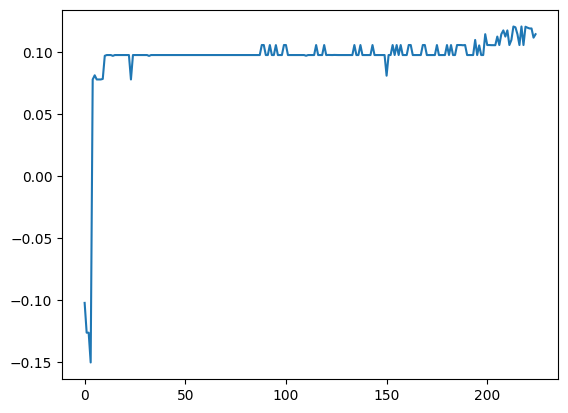

In [ ]:
PPO = PPO_Clip(hiperparams, device )
rewards = PPO.train(env)
plt.plot(rewards)
plt.show()

torch.save(PPO.policy_net.state_dict(), "trained_net/flappy_actor2.pth")
torch.save(PPO.value_net.state_dict(), "trained_net/flappy_critic2.pth")

In [8]:
env = gymnasium.make("FlappyBird-v0", render_mode = "human", use_lidar=False)
PPO = PPO_Clip(hiperparams, device )

policy_net = PolicyNet(12, 2)
policy_net.load_state_dict(torch.load("trained_net/flappy_actor.pth", map_location=device))
policy_net.eval()
PPO.policy_net = policy_net
PPO.evaluate(env, 5)
env.close()